# PyTorch Fundamentals and MNIST Classification

Welcome to this lab notebook on **PyTorch basics** and **MNIST** digit classification.

# Why This PyTorch Introduction is Important for You

This lab is designed to:

- Give you hands-on experience with PyTorch.
- Help you see how optimization works in practice.
- Show you what is happening under the hood once, so that later you can rely on the framework without confusion.

Let's get started!


## 1. Tensors and Tensor Operations
**Why you should care:**  
Tensors are the core data structure in deep learning. They hold both the **data** and the **parameters** (weights and biases) that we optimize.
In practice, you won’t always create random tensors by hand, but understanding how they work is important because optimization happens inside these structures.



### Install and Import Dependencies

Reccomendation:
In case you haven't installed `torch` or `torchvision` yet, do in a custom enviroment for this class using conda

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

print("PyTorch version:", torch.__version__)


PyTorch version: 2.8.0+cu126



Tensors are multi-dimensional arrays (like NumPy arrays) but with added functionality for GPU acceleration and autograd.
They play a central role in deep learning frameworks like PyTorch and TensorFlow, where they enable rapid experimentation with neural network architectures by transparently handling the computational graph. This means every operation on a tensor is tracked so that gradients can be calculated automatically during backpropagation. In addition, they can be seamlessly moved between CPUs, GPUs, or other accelerators, making it easier to scale performance-intensive computations across different hardware.
Lets play!

### 1.1 Creating and Inspecting Tensors

Consult the [PyTorch docs](https://pytorch.org/docs/stable/tensors.html) for details on tensor creation (`torch.tensor`, `torch.zeros`, etc.).

**Clarification:**
Scalars are useful for simple values (like a learning rate). Vectors and matrices are common for weights or data samples. 4D tensors appear in computer vision, where you store batches of images.

**Task 1. Create a scalar tensor named `scalar_t` with any integer and print it**
A scalar tensor is simply a tensor with zero dimensions. Scalars are the simplest form of data in PyTorch. Understanding how PyTorch stores and manages them provides a good foundation for working with higher-dimensional tensors (vectors, matrices, etc.).

In [2]:
scalar_t = torch.tensor(7)
print('Scalar tensor:', scalar_t)

Scalar tensor: tensor(7)


**Task 2. Print its shape**
In PyTorch, a 1D tensor (often referred to as a vector) is simply a tensor with one dimension

In [3]:
print('Shape of scalar_t:', scalar_t.shape)  # torch.Size([])

Shape of scalar_t: torch.Size([])


**Task 3. When do you think you would use this type of tensor?**

Scalars are used for single-value parameters like learning rates, loss values, or constants

**Task 4. Create a 1D tensor (e.g., [0,1,2,3,4]) named `vector_t`. Print it and print its shape**

In [4]:
vector_t = torch.tensor([0,1,2,3,4])
print('Vector tensor:', vector_t)
print('Shape:', vector_t.shape)

Vector tensor: tensor([0, 1, 2, 3, 4])
Shape: torch.Size([5])


**Task 5. When do you think you would use this type of tensor?**

1D tensors (vectors) are useful for feature vectors, weight vectors, or label arrays

**Task 6. Create a 2D tensor named `matrix_t` with shape (2,3). Print the second row.**
 A 2D tensor in PyTorch can be viewed as a matrix, which has two dimensions: rows and columns.

In [5]:
matrix_t = torch.tensor([[1,2,3],[4,5,6]])
print('Matrix tensor:\n', matrix_t)
print('Second row:', matrix_t[1])


Matrix tensor:
 tensor([[1, 2, 3],
        [4, 5, 6]])
Second row: tensor([4, 5, 6])


**Task 7. When do you think you would use this type of tensor?**

2D tensors (matrices) are used for datasets (rows=samples, cols=features) or weight matrices

**Task 8. Create a 4D tensor `images_t` of all zeros with size (5, 3, 32, 32). Print it and print its shape**
A 4D tensor can be thought of as a higher-dimensional array. In deep learning, a common example is an image batch tensor with shape

In [6]:
images_t = torch.zeros((5,3,32,32))
print('Images tensor shape:', images_t.shape)

Images tensor shape: torch.Size([5, 3, 32, 32])


### 1.2 Tensor Computations

Basic Tensor Operations in PyTorch

Below is an extended list of fundamental operations you can perform on PyTorch tensors, including **flattening** and **transformations** like reshaping.

In [7]:
# Element-Wise Addition
# Adds corresponding elements of two tensors (of the same shape or broadcastable shapes).


a = torch.tensor([1, 2, 3])
b = torch.tensor([4, 5, 6])

c = a + b
c

tensor([5, 7, 9])

In [8]:
# Create a 2D tensor with two rows and three columns
x = torch.tensor([[1, 2, 3],
                  [4, 5, 6]])

# 1) Sum over the entire tensor (all elements):
#    1 + 2 + 3 + 4 + 5 + 6 = 21
total_sum = x.sum()  # tensor(21)

# 2) Sum along a specific dimension (dim=0 collapses rows):
#    Summation is done column-by-column:
#    [ (1+4), (2+5), (3+6) ] = [5, 7, 9 ]
sum_along_dim0 = x.sum(dim=0)  # tensor([5, 7, 9])
print("Sum along dim=0 (columns):", sum_along_dim0)



Sum along dim=0 (columns): tensor([5, 7, 9])


In [9]:
y = torch.tensor([[1.0, 2.0],
                  [3.0, 4.0]])

# Mean over the entire tensor
mean_all = y.mean()  # tensor(2.5)

# Mean along dimension 1
mean_dim1 = y.mean(dim=1)  # tensor([1.5, 3.5])

In [10]:
# Create a 2D tensor with two rows and three columns
orig_tensor = torch.tensor([
    [1, 2, 3],
    [4, 5, 6]
])

# Flatten the 2D tensor into a 1D tensor by "viewing" all elements in a single dimension.
# '-1' tells PyTorch to figure out the size automatically.
flattened = orig_tensor.view(-1)
# Result: tensor([1, 2, 3, 4, 5, 6])
print("Flattened tensor:", flattened)

# Create a 3D tensor of shape (2, 3, 4) with random values
tensor_3d = torch.randn(2, 3, 4)

# Permute the dimensions: swap dimension 0 with dimension 1.
# Original shape: (2, 3, 4)
# New shape: (3, 2, 4)
permuted = tensor_3d.permute(1, 0, 2)
print("Original 3D shape:", tensor_3d.shape)
print("Permuted 3D shape:", permuted.shape)

Flattened tensor: tensor([1, 2, 3, 4, 5, 6])
Original 3D shape: torch.Size([2, 3, 4])
Permuted 3D shape: torch.Size([3, 2, 4])


**Task 9. Create a 2D PyTorch tensor with the values**

\\begin{bmatrix}
1 & 2 & 3 \\
4 & 5 & 6
\end{bmatrix}

Transpose it and confirm that its rows and columns have been swapped.

In [11]:
tensor_2d = torch.tensor([[1,2,3],[4,5,6]])
transposed = tensor_2d.t()
print('Original:\n', tensor_2d)
print('Transposed:\n', transposed)

Original:
 tensor([[1, 2, 3],
        [4, 5, 6]])
Transposed:
 tensor([[1, 4],
        [2, 5],
        [3, 6]])


**Clarification:**
Basic operations like sums, means, reshaping, and transposing matter because during optimization, we often need to aggregate gradients, flatten tensors for fully connected layers, or reshape data to flow through the model correctly.

## 2. Automatic Differentiation (Autograd)
**Why you should care:**  
Training neural networks requires calculating gradients to update model parameters. PyTorch's `autograd` feature automates this process, making it easier to optimize models and understand how they learn. Furthermore, PyTorch’s **dynamic computational graph** builds itself on-the-fly with each forward pass. Whenever you perform operations on tensors that track gradients, PyTorch records those operations in the graph. When you call `.backward()`, PyTorch traverses this graph in reverse (backpropagation) to compute gradients for every tensor involved, without requiring you to manually implement the derivative logic. This flexibility not only streamlines experimentation with **custom layers** and **unusual architectures** but also facilitates easier debugging, since you can inspect intermediate gradients at any point in the model.

### 2.1 Compute Gradients

Take a look at this example to compute gradient of
$$
(y = x^2)
$$
at the point
$$
(x = 3)
$$


In [12]:
# Create a tensor x with the value 3.0 and enable gradient tracking.
x = torch.tensor(3.0, requires_grad=True)

# Define the function y = x^2.
y = x ** 2

# Perform backpropagation to compute the gradient dy/dx.
y.backward()

# Extract the gradient stored in x.grad.
dy_dx = x.grad

# Print the gradient of y=x^2 at x=3. (Expect ~6.0 because the derivative of x^2 is 2x)
print("dy/dx of y=x^2 at x=3:", dy_dx)



dy/dx of y=x^2 at x=3: tensor(6.)


Here autograd computes
$$
𝑑𝑦/𝑑𝑥=6
$$
automatically. This is the same mechanism PyTorch uses to compute gradients of millions of parameters in a neural network during training.

### 2.2 Simple Gradient Descent on a Scalar Function
Now, we want to minimize:  

$$
L(x) = (x - x_f)^2
$$  

The minimum of this function occurs at:  

$$
x = 4
$$  

We'll use gradient descent to see how PyTorch can do it iteratively.  

The update rule is:  

$$
x \;\; \leftarrow \;\; x - \eta \frac{dL}{dx}
$$  

where $\eta$ is the learning rate.  

---

**Math Note: Why is the minimum at $x = 4$?**

1. Derivative:  

$$
\frac{dL}{dx} = 2(x - 4)
$$  

2. Set derivative = 0:  

$$
2(x - 4) = 0 \quad \Rightarrow \quad x = 4
$$  

3. Second derivative:  

$$
\frac{d^2L}{dx^2} = 2 > 0
$$  

Therefore, $x = 4$ is the **minimum point**.  


We’ll track the value of $x$ across iterations to see it converge toward this minimum.



**Task 10. Complete the code when the comments indicate it with ##**

Initial x: -0.32780539989471436


/tmp/ipython-input-65489508.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x_var = torch.tensor(x, requires_grad=True)


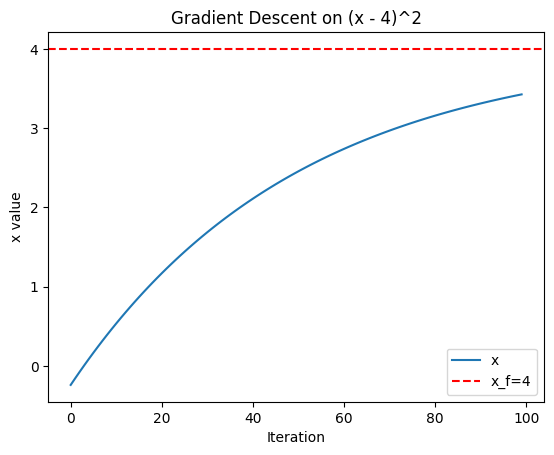

In [13]:
x_f = 4.0
x = torch.randn(1)
print('Initial x:', x.item())
learning_rate = 1e-2
history = []

for i in range(100):
    x_var = torch.tensor(x, requires_grad=True)
    loss = (x_var - x_f)**2  ## define loss
    loss.backward()          ## compute gradients
    x = x_var - learning_rate * x_var.grad  ## update
    history.append(x.item())

plt.plot(history, label='x')
plt.axhline(x_f, color='r', linestyle='--', label='x_f=4')
plt.legend()
plt.xlabel('Iteration')
plt.ylabel('x value')
plt.title('Gradient Descent on (x - 4)^2')
plt.show()

**Clarification:**
This is gradient descent in its simplest form. In practice, you won’t hand-code updates like this — PyTorch’s built-in optimizers (SGD, Adam, RMSProp) will do it for you. But running it once shows exactly what’s happening behind the scenes.

## 3. Building a Simple Neural Network
**Why you should care:**  
Creating your own neural network will help you understand how deep learning models are structured and function. You'll see how layers, activation functions, and weights work together to make predictions.

**What you'll gain:**  
- Experience in building neural networks step by step.  
- Knowledge of key components like layers and activation functions.  
- A better understanding of forward and backward passes in training.

We'll train a **Multi-Layer Perceptron (MLP)** for digit classification.
Steps:
1. **Load** MNIST data.
2. **Define** an MLP (subclassing `nn.Module`).
3. **Specify** loss function (CrossEntropy) & optimizer (SGD/Adam).
4. **Train** the network.
5. **Evaluate** on the test set.

### 3.1 Load the MNIST Dataset
Using `torchvision.datasets.MNIST` and `DataLoader`.

We'll normalize the images with mean=0.1307 and std=0.3081 (common practice for MNIST).

**Task 11. Complete the code when the comments indicate it with ##**

In [14]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])
train_dataset = torchvision.datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, transform=transform, download=True)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=1000, shuffle=False)
print('Shape of first image:', train_dataset[0][0].shape)
print('Label of first image:', train_dataset[0][1])
print('Number of training samples:', len(train_dataset))
print('Number of testing samples:', len(test_dataset))

100%|██████████| 9.91M/9.91M [00:00<00:00, 126MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 31.8MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 72.0MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.12MB/s]


Shape of first image: torch.Size([1, 28, 28])
Label of first image: 5
Number of training samples: 60000
Number of testing samples: 10000


### 3.2 Define a Simple MLP

We'll create a small neural network with the following architecture:

$$
28 \times 28 \rightarrow 128 \rightarrow 10
$$

- The input layer consists of \( 28 * 28 = 784 \) features, representing the flattened pixel values of the image.  
- A hidden layer with 128 neurons using the **ReLU** activation function:  

  $$
  h = \max(0, Wx + b)
  $$

- An output layer with 10 neurons (corresponding to digit classes 0-9), with **no activation function**, since we'll use **CrossEntropyLoss**, which internally applies the softmax function:

  $$
  \hat{y} = Wx + b
  $$

**Task 12. Complete the code when the comments indicate it with ##**

In [15]:
class SimpleMLP(nn.Module):
    def __init__(self):
        super(SimpleMLP, self).__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28*28, 128)
        self.fc2 = nn.Linear(128, 10)
    def forward(self, x):
        x = self.flatten(x)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = SimpleMLP()
print(model)

SimpleMLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


### 3.3 Define Loss and Optimizer

We commonly use **CrossEntropyLoss** for multi-class classification. Common optimizers include **SGD** (possibly with momentum) or **Adam**.

**Task 13. Complete the code when the comments indicate it with ##**

In [16]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)
# Alternative: optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

**Task 14. In your words:**
- How can you now tweak hyperparameters (batch size, learning rate, etc.), experiment with **SGD** vs. **Adam** vs. **RMSProp,** and maybe adding more layers or different activations

Hyperparameters like learning rate, batch size, optimizer choice, and network depth can be adjusted to control learning speed, accuracy, and generalization.

### 3.4 Training the Model

Training loop steps for each `epoch`:
1. **model.train()** to enable training mode.
2. Loop over **train_loader**:
    - Forward pass -> `outputs`.
    - Compute `loss`.
    - Zero gradients with `optimizer.zero_grad()`.
    - `loss.backward()`.
    - `optimizer.step()`.
3. Track average loss for each epoch.

**Task 15. Complete the COMMENTS when indicate it with ##**

In [17]:
num_epochs = 3
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        outputs = model(images)   ## forward: network predictions
        loss = criterion(outputs, labels) ## compute classification loss
        optimizer.zero_grad()     ## clear old gradients
        loss.backward()           ## backpropagate to compute gradients
        optimizer.step()          ## update weights
        running_loss += loss.item()
    epoch_loss = running_loss / len(train_loader)
    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}')

Epoch [1/3], Loss: 0.5893
Epoch [2/3], Loss: 0.3016
Epoch [3/3], Loss: 0.2558


**Clarification:**
This is gradient descent at scale. The sequence forward → loss → backward → step is the backbone of all optimization in deep learning.

### 3.5 Evaluate on Test Set

We switch the model to evaluation mode (`model.eval()`) and compute the **accuracy** on the test data.

In [18]:
# Set the model to evaluation mode (turns off dropout, batch normalization, etc.)
model.eval()

# Initialize variables to track the number of correctly classified samples and total samples
correct = 0
total = 0

# Disable gradient calculations during inference to improve efficiency and save memory
with torch.no_grad():
    # Iterate over the test dataset batches
    for images, labels in test_loader:
        # Perform forward pass to get model predictions (logits)
        outputs = model(images)

        # Get the class index with the highest probability (predicted label)
        _, predicted = torch.max(outputs, 1)

        # Update the total number of test samples
        total += labels.size(0)

        # Count the number of correct predictions
        correct += (predicted == labels).sum().item()

# Calculate accuracy as the percentage of correctly classified samples
accuracy = 100.0 * correct / total

# Print the final test accuracy
print(f"Test Accuracy: {accuracy:.2f}%")



Test Accuracy: 93.33%


**Task 16. In your words, explain what happend in the block code indcluded above for evaluating in the test**

During evaluation, the model is set to eval mode. Predictions are computed on test data without gradients. Correct predictions are counted and accuracy is reported.

**Implementation Gift: Visualize a batch of images with predictions**

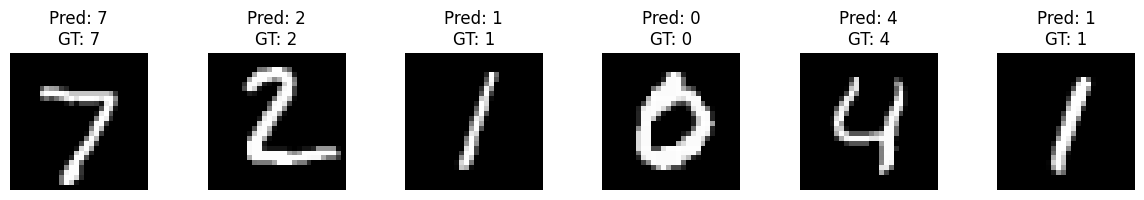

In [19]:
# Get a batch of test images and labels
model.eval()
images, labels = next(iter(test_loader))

# Forward pass to get outputs and predictions
outputs = model(images)
_, predicted = torch.max(outputs, 1)

# Pick how many samples to visualize
num_samples_to_show = 6
fig, axes = plt.subplots(1, num_samples_to_show, figsize=(12, 2))

for i in range(num_samples_to_show):
    # Move from PyTorch tensor -> NumPy for plotting
    img = images[i].squeeze().numpy()
    ax = axes[i]
    ax.imshow(img, cmap='gray')

    # Set title: prediction vs ground truth
    ax.set_title(f"Pred: {predicted[i].item()}\nGT: {labels[i].item()}")
    ax.axis('off')

plt.tight_layout()
plt.show()


**Final Reflection**

- You practiced using tensors, autograd, gradient descent, and a full training loop.
- In practice, you won’t code autograd or parameter updates manually — but now you know what they are doing under the hood.
- Optimization is the unifying thread: it drives every update from a simple scalar
𝑥 to the millions of weights in a neural network.